# Question 3: SMB Bundle Dashboard

## Assignment

<!-- Original Q3 assignment prompt from `Business Case for BA 2026 - SMB Bundles.pdf`. Do not edit unless specifically requested. -->

> **Question 3: How do we monitor the sales?**
>
> Flashforward to after the launch of the SMB Bundles. Thanks to your outreach prioritization we have done several subsequent batches of calls, and bundle registrations have been coming in. In the third dataset you can find an overview of SMB sellers from both SYI and Pro, showing which bundle they purchased, with a start and end date.
>
> As a promotion, the first 28 days are for free. After that they pay:
>
> - €19.99 per 4 weeks for a Basic bundle
> - €49.99 per 4 weeks for a Plus bundle
>
> Every seller can only get a discount once. They can stop their bundle, or switch to another one at any point in the month. For this business case, assume they immediately pay for the full 4 weeks (unless it’s their first bundle ever and thus get a discount), and do not get a refund for any time left in their previous bundle.
>
> Design and present a dashboard that will help you show the impact of our Bundle introduction, and any other important analysis or metrics. The dashboard should both be useful at the launch and at the later stages. Use the data that is available to already fill parts of your dashboard design, while clearly stating what other data you would need to complete your view.

## 0. Data Structure

In [1]:
import importlib

from IPython.display import Markdown, display

import functions

functions = importlib.reload(functions)
pd = functions.pd
plt = functions.plt

functions.set_plot_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.1f}".format)


In [2]:
dashboard = functions.q3_dashboard_data()

bundle_df = dashboard["bundle_df"]
launch_start = dashboard["launch_start"]
dashboard_reference_date = dashboard["dashboard_reference_date"]
seller_fields = dashboard["seller_fields"]
weekly_metrics = dashboard["weekly_metrics"]
revenue_4w = dashboard["revenue_4w"]
revenue_by_bundle = dashboard["revenue_by_bundle"]
registrations_4w = dashboard["registrations_4w"]
cohort_metrics_28d = dashboard["cohort_metrics_28d"]
segment_metrics = dashboard["segment_metrics"]


In [3]:
print(f"Dashboard reference date: {dashboard_reference_date:%Y-%m-%d}")
print(f"Launch start date: {launch_start:%Y-%m-%d}")

display(functions.q3_structure_summary(bundle_df, dashboard_reference_date))
display(functions.q3_distribution_summary(bundle_df))


Dashboard reference date: 2025-04-29
Launch start date: 2024-02-29


,Metric,Value
0,Rows,"8,830"
1,Unique sellers,"4,076"
2,Start date range,2024-02-29 to 2025-04-29
3,Finite end date range,2024-03-04 to 2025-04-29
4,Open-ended rows,"4,094"
5,Missing values,0
6,Duplicate rows,0
7,Sellers with potential overlapping intervals,18


,Field,Value,Rows
0,Customer type,SYI,6802
1,Customer type,Pro,2028
2,Bundle,Basic,3777
3,Bundle,No bundle,2728
4,Bundle,Plus,2325


### 0.1 EDA Snapshot

- **Finding:** the file supports launch monitoring, not full business impact.
- **Why it matters:** use it for adoption, paid-base, and early quality signals.

In [4]:
display(
    functions.q3_short_eda_summary(
        bundle_df,
        seller_fields,
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
    )
)


,Metric,Value
0,First bundle starters,"4,076"
1,Basic-first share,68.5%
2,Plus-first share,31.5%
3,Peak weekly registrations,432 in week of 2024-04-01
4,Latest active paid bundles,"2,709"
5,Latest active trial bundles,0
6,Current no-bundle sellers,"1,367"
7,Current Plus share of paid base,40.9%
8,Sellers with multiple bundle periods,"1,545"
9,Sellers using both Basic and Plus,"1,042"


### 0.2 Customer Type Deep Dive

- **Finding:** customer type changes segment size more than bundle quality.
- **Why it matters:** keep customer type as a filter, not the main steering signal.

In [5]:
display(functions.q3_customer_type_eda_display_table(bundle_df, seller_fields))

,Customer type,Bundle starters,Basic-first share,Plus-first share,Active paid bundles,Plus share of active paid bundles,Current no-bundle share,Multiple bundle-period share,Used Basic and Plus share
0,SYI,"3,137",69.2%,30.8%,"2,093",40.9%,33.3%,38.1%,26.1%
1,Pro,939,66.1%,33.9%,616,40.7%,34.4%,37.3%,23.7%


In [6]:
display(Markdown(functions.q3_customer_type_insights_markdown(bundle_df, seller_fields)))

- **Pro sellers are a smaller part of the file**  
  Evidence: Pro: 939 starters; SYI: 3,137 starters.  
  Interpretation: Customer type matters for sizing, but not necessarily for quality.
- **Pro starts slightly more often on Plus**  
  Evidence: Plus-first share: Pro 33.9%; SYI 30.8%.  
  Interpretation: This is directionally useful for positioning, but the gap is modest.
- **Paid mix is nearly the same**  
  Evidence: Paid Plus share: Pro 40.7%; SYI 40.9%.  
  Interpretation: Customer type alone does not strongly separate monetization quality.
- **No-bundle share is also similar**  
  Evidence: No-bundle share: Pro 34.4%; SYI 33.3%.  
  Interpretation: Customer type is not a strong churn/status signal in this dataset.

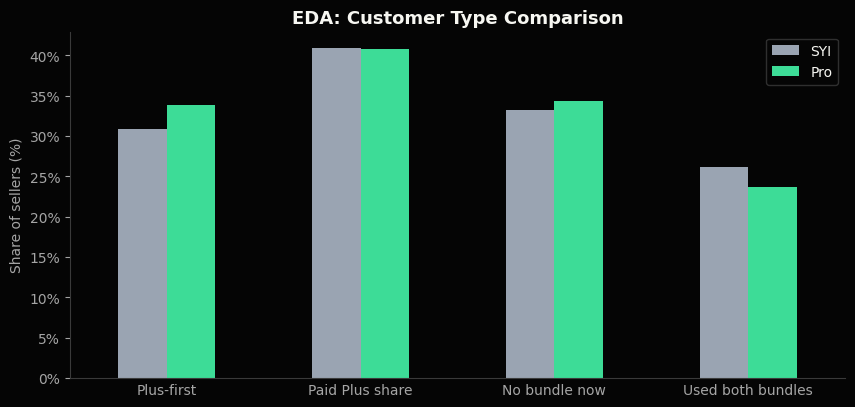

In [7]:
functions.plot_q3_customer_type_comparison(bundle_df, seller_fields)
plt.show()

### 0.3 Launch Demand Was Front-Loaded

- **Finding:** registrations peaked soon after launch, then fell to a lower run-rate.
- **Why it matters:** after launch, focus more on paid base and retention than raw starts.

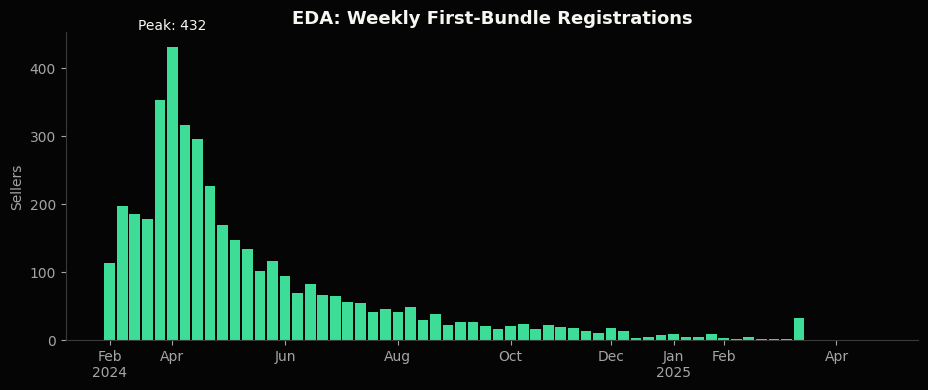

In [8]:
functions.plot_q3_eda_launch_demand(weekly_metrics)
plt.show()


### 0.4 Basic Drives Entry, Plus Drives Monetization

- **Finding:** most sellers start on Basic, but Plus has a higher share of the current paid base.
- **Why it matters:** Basic tracks adoption; Plus share tracks monetization quality.

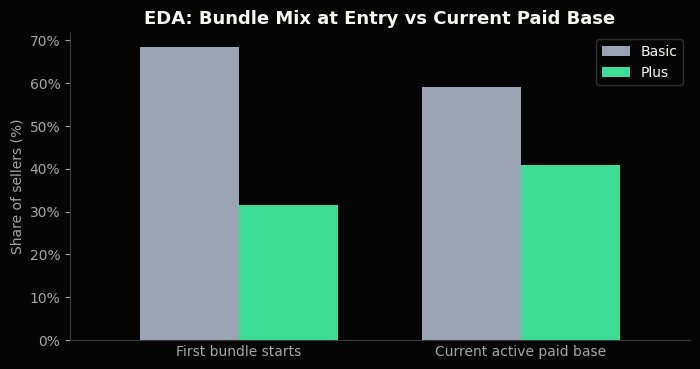

In [9]:
functions.plot_q3_eda_bundle_mix_shift(seller_fields)
plt.show()


### 0.5 Current Status Includes No Bundle

- **Finding:** many bundle starters now have a current `No bundle` interval.
- **Why it matters:** `No bundle` means the seller is currently not on Basic or Plus.

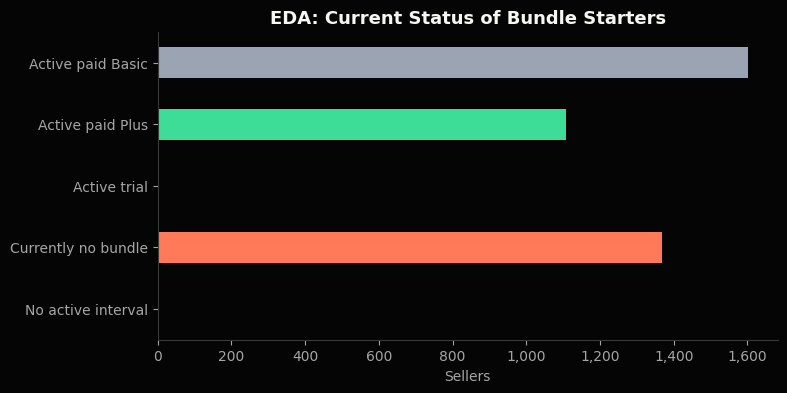

In [10]:
functions.plot_q3_eda_current_status(seller_fields)
plt.show()


### 0.6 Bundle Status Over Time

- **Finding:** sellers shifted from no bundle into Basic and Plus after launch.
- **Why it matters:** this shows bundle adoption and the remaining no-bundle pool together.

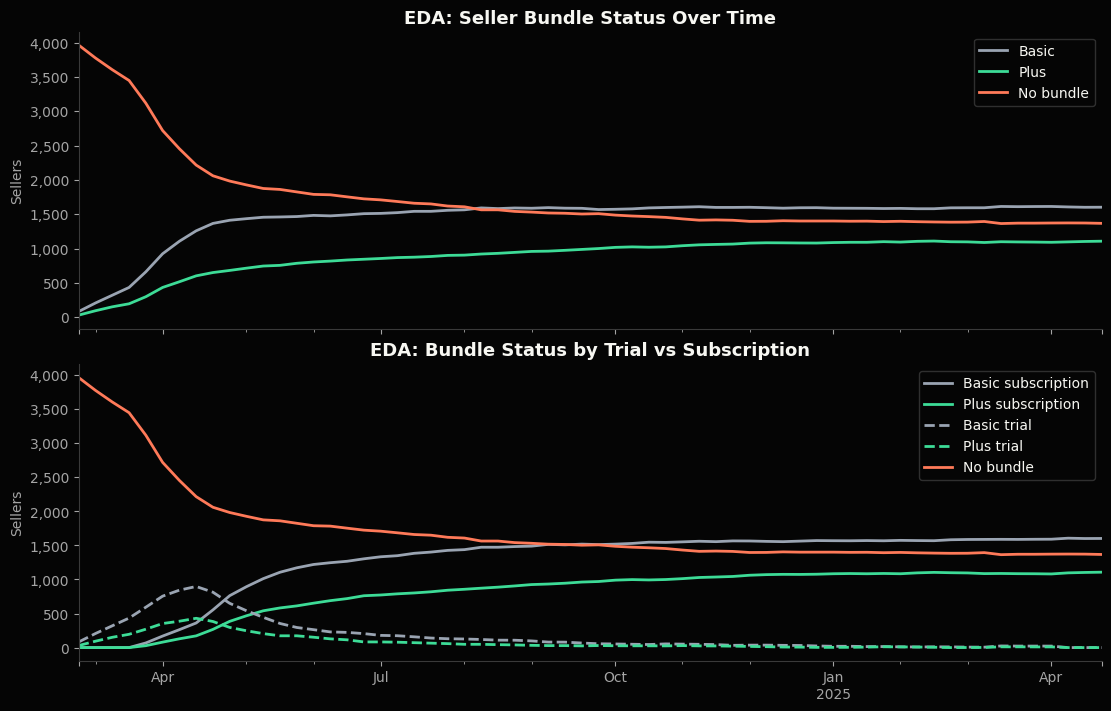

In [11]:
functions.plot_q3_eda_bundle_status_timeseries(
    bundle_df,
    seller_fields,
    launch_start,
    dashboard_reference_date,
)
plt.show()


### 0.7 Open-Ended Means Still Active

- **Finding:** many rows end on `2099-12-31`.
- **Why it matters:** treat these rows as active intervals, not real future end dates.

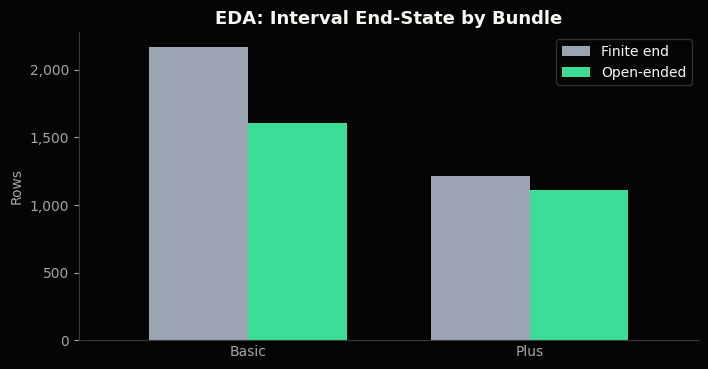

In [12]:
functions.plot_q3_eda_open_ended_intervals(bundle_df)
plt.show()


### 0.8 Repeat Bundle Periods and Switching Are Common

- **Finding:** many sellers have repeat bundle periods; some used both Basic and Plus.
- **Why it matters:** dashboard metrics must handle renewals, stops, and switches.

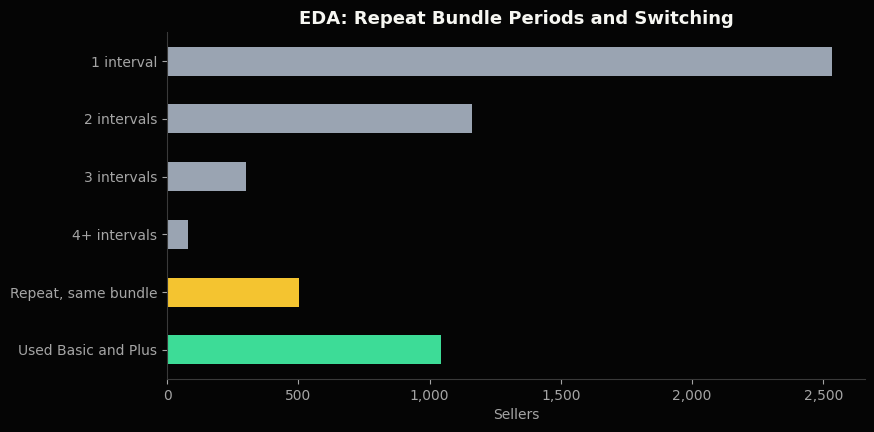

In [13]:
functions.plot_q3_eda_interval_complexity(bundle_df)
plt.show()


## 1. Dashboard Framing

- **Goal:** monitor whether SMB Bundles are gaining traction, converting to paid usage, and creating measurable value.
- **Structure:** three dashboard views, each answering a different business question.
- **Default view:** all sellers. Use filters only to diagnose differences.
- **Current scope:** the registration file supports adoption, paid-base, modeled revenue, and early quality. Full impact needs extra revenue and seller-outcome data.

| View | Goal | Main question | Required enrichments |
| --- | --- | --- | --- |
| Sales Overview | Track launch traction and monetized adoption | Are bundles gaining commercial traction? | Actual invoiced revenue and payment status |
| Customer Quality | Monitor conversion, retention, and segment differences | Are registrations becoming retained paid customers? | Seller size, category, spend tier, outreach batch |
| Business Impact | Quantify value for Marktplaats and sellers | Are bundles creating measurable value? | Actual invoiced revenue and seller outcome data |


## 2. Sales Overview

- Are SMB Bundles gaining commercial traction?

### 2.1 KPI Snapshot

- **Question:** what is the latest headline readout?
- **Read:** current active bundles, rolling 4-week registrations, Plus share, and latest complete 4-week modeled revenue.
- **Caveat:** snapshot combines current status, rolling windows, and complete-period revenue.

In [14]:
display(
    functions.q3_sales_kpis(
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
        registrations_4w,
        seller_fields,
    )
)


,Reference date,Active paid bundles,Active trial bundles,New registration in 4wk,Plus share of active paid bundles,Modeled revenue in latest complete 4wk period
0,2025-04-29,"2,709 (+0% w/w)",0 (+0% w/w),41 (+156% vs prior 4wk),40.9% (+0.1pp w/w),"€88,373 (+0% vs prev 4wk)"


### 2.2 Weekly New Registrations

- **Question:** is launch demand growing, stable, or fading?
- **Read:** weekly first bundle starts, split by Basic and Plus.
- **Caveat:** registrations include trial starts, not paid subscriptions.
- **Controls:** date range, customer type, bundle.

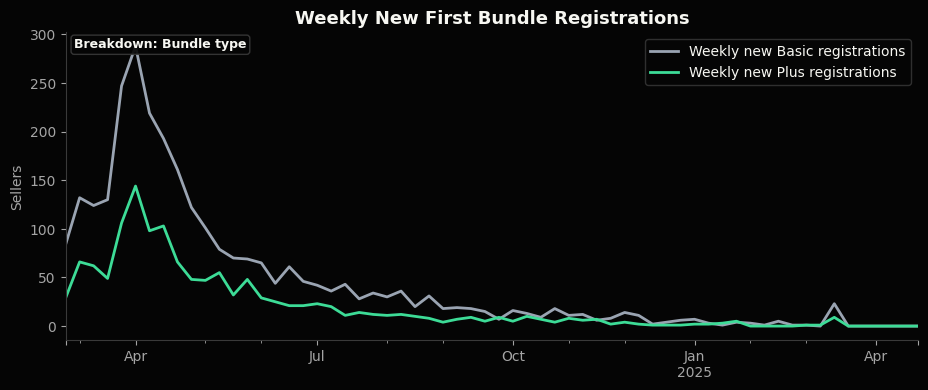

In [15]:
functions.plot_q3_weekly_new_registrations(weekly_metrics)
plt.show()


### 2.3 Active Bundles

- **Question:** is the bundle base turning into paid adoption?
- **Read:** paid vs trial bundles over time. Solid lines are paid; dashed lines are trial.
- **Caveat:** active status comes from registration intervals, not payment records.
- **Controls:** date range, customer type, bundle.

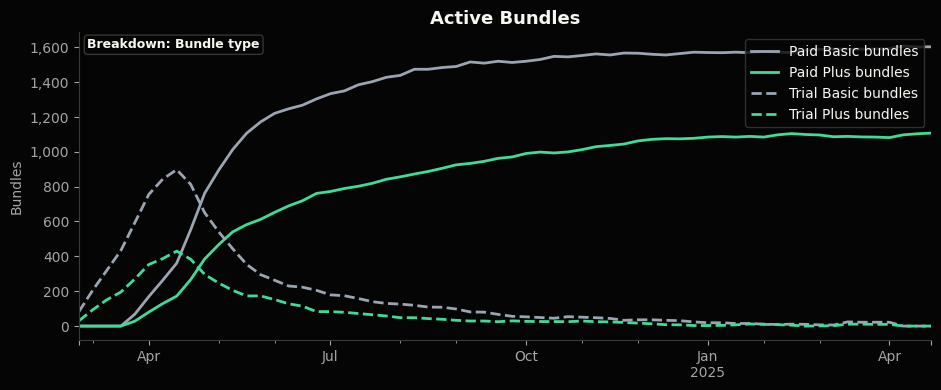

In [16]:
functions.plot_q3_active_bundle_sellers(weekly_metrics)
plt.show()

### 2.4 Plus Share

- **Question:** is the paid base shifting toward Plus?
- **Read:** Plus share of active paid bundles over time.
- **Controls:** date range and customer type.

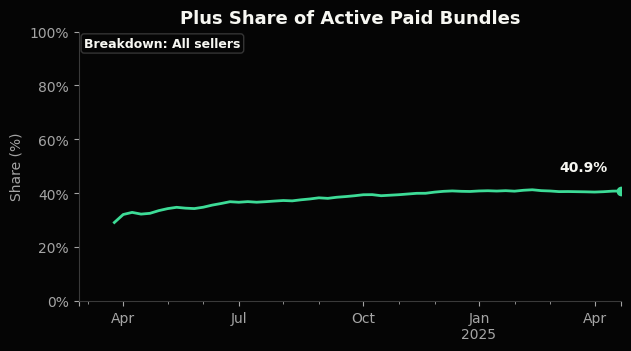

In [17]:
functions.plot_q3_plus_share(weekly_metrics)
plt.show()


## 3. Customer Quality

- Are registrations becoming retained paid customers?

### 3.1 Cohort Health

- **Question:** do cohorts stay active paid after trial and later billing cycles?
- **Read:** 28-day cohorts by first bundle start; darker cells mean higher active paid rate.
- **Caveat:** blank cells are immature checkpoints, not zero conversion.

In [18]:
display(functions.q3_cohort_heatmap_table(cohort_metrics_28d))

### 3.2 Segment Health Snapshot

- **Question:** which segments look stronger now?
- **Read:** current snapshot by available cuts: customer type, first bundle type, and current bundle status.
- **Caveat:** stronger sales steering needs seller-size, spend, and outreach data.

In [19]:
display(functions.q3_segment_display_table(segment_metrics))

display(Markdown(functions.q3_markdown_table(functions.q3_segment_enrichment_opportunities())))

,Segment,Segment value,Registrations,Day-28 paid conversion,Plus share of active paid bundles,Active paid bundles,Current no-bundle share
0,Current bundle status,Basic,"1,602",93.4%,0.0%,"1,602",0.0%
1,Current bundle status,No bundle,"1,367",83.3%,,0,100.0%
2,Current bundle status,Plus,"1,107",90.2%,100.0%,"1,107",0.0%
3,Customer type,SYI,"3,137",89.1%,40.9%,"2,093",33.3%
4,Customer type,Pro,939,89.5%,40.7%,616,34.4%
5,First bundle type,Basic-first,"2,791",89.4%,25.5%,"1,845",33.9%
6,First bundle type,Plus-first,"1,285",88.7%,73.6%,864,32.8%


| Potential merge | Why it helps |
| --- | --- |
| SMB likelihood score | Separates likely business sellers from lighter consumer-like sellers. |
| Outreach readiness score | Shows whether sales-prioritized sellers convert and retain better. |
| Historical spend tier | Distinguishes high-value sellers from low-spend adopters. |
| Seller size / activity tier | Identifies whether bundles work better for large or small sellers. |
| Pro performance tier | Separates Pro sellers with real traffic from Pro sellers with low engagement. |
| Seller outcome tier | Shows whether bundles create value for sellers, not only platform revenue. |
| Outreach batch / channel | Connects launch execution to registration and paid conversion quality. |

#### Segment Change Alerts

- **Question:** which segments changed sharply in the last 4 weeks?
- **Read:** biggest increases and declines in the selected metric.
- Dummy data, not measured results.

In [20]:
display(Markdown(functions.q3_markdown_table(functions.q3_segment_module_descriptions())))

| Module | Potential merged data | What it would show |
| --- | --- | --- |
| Recent change alerts | Daily or weekly segment snapshots joined to registration history | Sharp 4-week changes in active paid bundles, no-bundle share, or Plus share. |

##### Recent Segment Change Alerts

- **What is shown:** largest recent changes in active paid rate by segment.
- **Why it matters:** highlights where follow-up is most urgent.

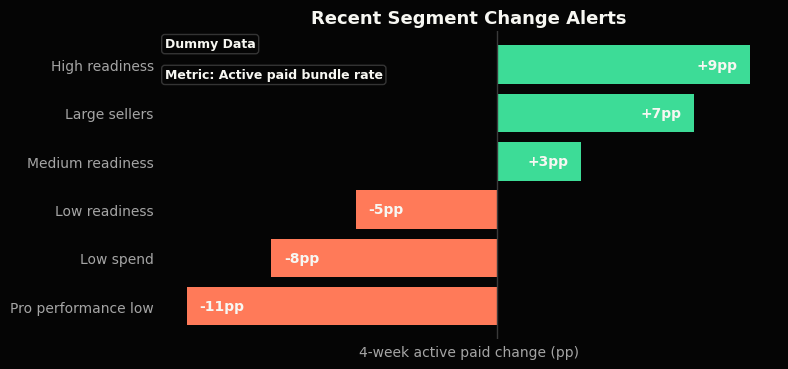

In [21]:
functions.plot_q3_segment_change_alerts()
plt.show()

## 4. Business Impact

- Are bundles creating measurable value for Marktplaats and sellers?
- **Current data supports:** modeled paid revenue and bundle revenue mix.
- **Still missing:** actual invoiced revenue and seller outcome data.

### 4.1 Modeled Paid Revenue

- **Question:** is paid adoption translating into subscription revenue?
- **Read:** modeled 4-week paid revenue and Basic vs Plus revenue mix.
- **Caveat:** modeled from intervals and list prices; not invoiced or incremental revenue.

,period_start,modeled_paid_revenue_eur,paid_billing_events
8,2024-10-10,"€84,993","2,670"
9,2024-11-07,"€87,303","2,727"
10,2024-12-05,"€87,573","2,721"
11,2025-01-02,"€88,243","2,738"
12,2025-01-30,"€88,723","2,744"
13,2025-02-27,"€88,123","2,735"
14,2025-03-27,"€88,373","2,746"
15,2025-04-24,"€21,144",648


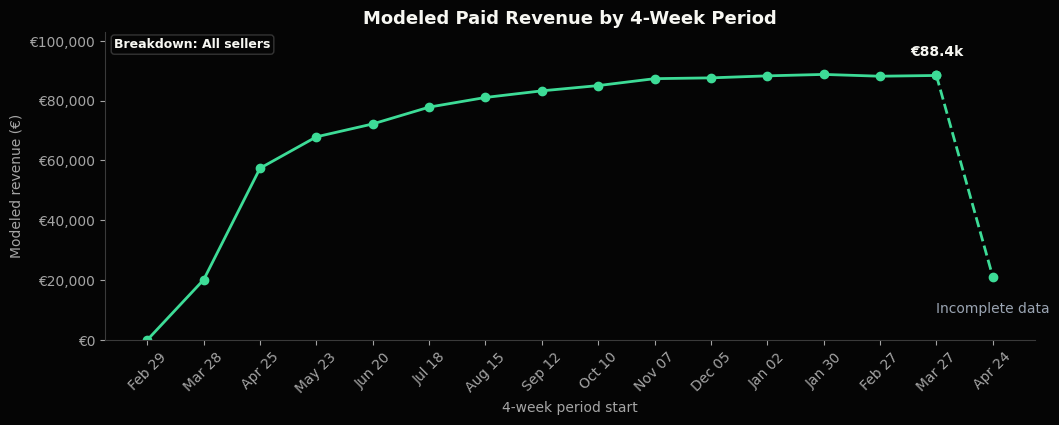

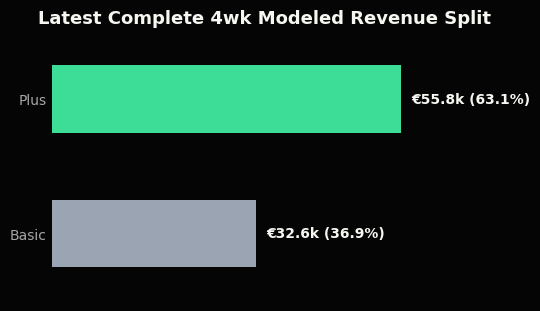

In [22]:
display(functions.q3_revenue_display_table(revenue_4w))

functions.plot_q3_modeled_revenue(revenue_4w, dashboard_reference_date)
plt.show()

functions.plot_q3_latest_revenue_by_bundle(revenue_by_bundle, dashboard_reference_date)
plt.show()

### 4.2 Seller Outcome Uplift

- **Question:** do bundles help sellers generate more leads?
- **Read:** lead uplift vs pre-bundle baseline, split by Basic and Plus.
- Dummy data, not measured results.

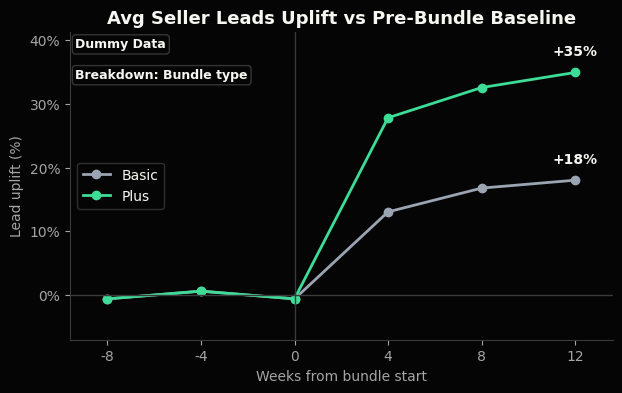

In [23]:
functions.plot_q3_seller_leads_uplift()
plt.show()
